# Analyze and plot results for networks

This script takes in the results from run_over_regs.sh, assembles them into a single dataset, and performs analyses on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
from pydmd import DMD
import os
import plotly.graph_objects as go
import plotly.express as px

# import clustering packages
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import seaborn as sns
from celluloid import Camera

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

from stoch_sim_model import *

## 0. Load data and build datasets

In [2]:
# Load data from 2nd infections
infection_type = 'prim'
reg_model = ''
runs = '-1-'
comment = "test-Nact-Ediv-vir" #"full-reg-vir" #"act-reg-exp-reg" # mem-reg

d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/stacked_data'+runs+'runs'+'-'+comment+'.npy'
#d_std = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/std/stacked_data'+runs+'runs'+'-'+comment+'.npy'


mean_data = np.load(d_mean)
#std_data = np.load(d_std)

# create dataframe of infection response statistics
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
mean_df = pd.DataFrame(mean_data, columns = [i for i in var_names]).dropna(thresh=1)
#std_df = pd.DataFrame(std_data, columns = [i for i in var_names])

with pd.option_context('display.max_columns', None):
    display(mean_df)

,S_0,I_0,b_I,d_S,d_I,d_IE,d_IH,K_IE,K_IH,A_init,b_Ain,b_H,d_H,K_EI,K_EH,N_0,max_Na,b_myc,d_myc,myc_thresh,t_act,t_bind,t_Na_div,t_E_div,t_M_div,t_EM_diff,t_E_die,t_E_cyt,psi_Nact_I,psi_Nact_H,psi_Nact_IH,psi_NM_I,psi_NM_H,psi_NM_IH,psi_EM_I,psi_EM_H,psi_EM_IH,psi_Ediv_I,psi_Ediv_H,psi_Ediv_IH,p_load,s_load,T_max_pI,T_min_pI,harm_pI,harm_sI,harm_pS,harm_sS,max_pE,max_sE,T_max_pE,T_max_sE,inf_pM,inf_sM,init_M,int_pE,int_sE,int_pH,int_sH,min_pS,min_sS
0,10000000.0,1000.0,7.500000e-08,0.01,0.2,12.0,0.0,10000.0,5000.0,1000.0,1.0,1.0,2.0,10000.0,5000.0,100.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,15.0,2.0,0.666667,-3.140185e-16,-4.0,-1.332268e-15,0.0,0.0,0.0,0.0,0.0,0.0,-3.140185e-16,-4.0,-1.332268e-15,1.944601e+04,1.944601e+04,3.996,5.128,1.550254e+04,1.550254e+04,168527.208782,168527.208782,42949.0,42949.0,11.076,11.076,7751.0,7751.0,3424.0,155878.512,155878.512,1.944552e+03,1.944552e+03,9.825848e+06,9.825848e+06
1,10000000.0,1000.0,7.500000e-08,0.01,0.2,12.0,0.0,10000.0,5000.0,1000.0,1.0,1.0,2.0,10000.0,5000.0,100.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,15.0,2.0,0.666667,-3.140185e-16,-4.0,-1.332268e-15,0.0,0.0,0.0,0.0,0.0,0.0,-3.140185e-16,-4.0,1.332268e-15,2.064856e+07,2.064856e+07,19.444,0.000,8.028405e+06,8.028405e+06,1816.910181,1816.910181,686.0,686.0,7.248,7.248,36.0,36.0,20.0,1697.396,1697.396,1.870512e+06,1.870512e+06,2.303030e+06,2.303030e+06
2,10000000.0,1000.0,7.500000e-08,0.01,0.2,12.0,0.0,10000.0,5000.0,1000.0,1.0,1.0,2.0,10000.0,5000.0,100.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,15.0,2.0,0.666667,-3.140185e-16,-4.0,-1.332268e-15,0.0,0.0,0.0,0.0,0.0,0.0,5.000000e-01,-3.5,-4.440892e-16,1.589749e+04,1.589749e+04,3.664,4.752,1.283296e+04,1.283296e+04,151583.054067,151583.054067,44689.0,44689.0,15.784,15.784,8737.0,8737.0,4207.0,140037.740,140037.740,1.589701e+03,1.589701e+03,9.847784e+06,9.847784e+06
3,10000000.0,1000.0,7.500000e-08,0.01,0.2,12.0,0.0,10000.0,5000.0,1000.0,1.0,1.0,2.0,10000.0,5000.0,100.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,15.0,2.0,0.666667,-3.140185e-16,-4.0,-1.332268e-15,0.0,0.0,0.0,0.0,0.0,0.0,5.000000e-01,-3.5,4.440892e-16,1.669109e+04,1.669109e+04,3.736,4.856,1.343379e+04,1.343379e+04,142588.956958,142588.956958,38338.0,38338.0,5.760,5.760,1963.0,1963.0,34.0,131688.180,131688.180,1.669060e+03,1.669060e+03,9.859391e+06,9.859391e+06
4,10000000.0,1000.0,7.500000e-08,0.01,0.2,12.0,0.0,10000.0,5000.0,1000.0,1.0,1.0,2.0,10000.0,5000.0,100.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,15.0,2.0,0.666667,-3.140185e-16,-4.0,-1.332268e-15,0.0,0.0,0.0,0.0,0.0,0.0,1.000000e+00,-3.0,0.000000e+00,4.210630e+04,4.210630e+04,5.128,7.120,3.234235e+04,3.234235e+04,39276.546085,39276.546085,10420.0,10420.0,14.396,14.396,2244.0,2244.0,1118.0,36198.452,36198.452,4.210580e+03,4.210580e+03,9.936564e+06,9.936564e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209003,10000000.0,1000.0,1.000000e-07,0.01,0.5,12.0,0.0,1000000.0,5000.0,1000.0,1.0,1.0,2.0,1000000.0,5000.0,100.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,15.0,2.0,0.666667,3.140185e-16,4.0,1.332268e-15,0.0,0.0,0.0,0.0,0.0,0.0,-5.000000e-01,-2.5,-1.000000e+00,9.689303e+06,9.689303e+06,18.360,0.000,6.288341e+06,6.288341e+06,4426.546406,4426.546406,1039.0,1039.0,12.188,12.188,116.0,116.0,57.0,4423.740,4423.740,2.236586e+06,2.236586e+06,3.976994e+06,3.976994e+06
209004,10000000.0,1000.0,1.000000e-07,0.01,0.5,12.0,0.0,1000000.0,5000.0,1000.0,1.0,1.0,2.0,1000000.0,5000.0,100.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,15.0,2.0,0.666667,3.140185e-16,4.0,1.332268e-15,0.0,0.0,0.0,0.0,0.0,0.0,-1.570092e-16,-2.0,2.000000e+00,9.694609e+06,9.694609e+06,18.356,0.000,6.290499e+06,6.290499e+06,4304.579462,4304.579462,934.

## 1. Understanding the statistics of responses to an infection

In [4]:
# Create additional variables
K_IEs = np.unique(mean_df['K_IE'])
d_Is = np.unique(mean_df['d_I'])
b_S = np.mean(mean_df['d_S']*mean_df['S_0'])
N_0 = np.mean(mean_df['N_0'])
virs = np.unique(mean_df[['d_I','K_IE','b_I']].to_numpy(), axis = 0)
NM_reg = ['psi_NM_I', 'psi_NM_H', 'psi_NM_IH']
EM_reg = ['psi_EM_I', 'psi_EM_H', 'psi_EM_IH']
Nact_reg = ['psi_Nact_I', 'psi_Nact_H', 'psi_Nact_IH']
Ediv_reg = ['psi_Ediv_I', 'psi_Ediv_H', 'psi_Ediv_IH']
reg = Nact_reg + NM_reg + EM_reg + Ediv_reg #NM_reg + EM_reg #Nact_reg #+ Ediv_reg

mean_df['int_presp'] = mean_df['int_pE'] + mean_df['inf_pM']
mean_df['int_sresp'] = mean_df['int_sE'] + mean_df['inf_sM']
# identify Biologically evidenced networks
mean_df['bio_reg'] = (mean_df[EM_reg[0]] > 0.0)*(mean_df[EM_reg[1]] > 0.0)*(mean_df[EM_reg[2]] > 0.0)*1

# std_df['harm_pI_scaled'] = std_df['harm_pI']/(b_S)
# std_df['harm_sI_scaled'] = std_df['harm_sI']/(b_S)
# std_df['harm_pS_scaled'] = std_df['harm_pS']/(b_S)
# std_df['harm_sS_scaled'] = std_df['harm_sS']/(b_S)
# std_df['harm_pIS_scaled'] = np.sqrt(std_df['harm_pI']**2 + std_df['harm_pS']**2)/(b_S)
# std_df['harm_sIS_scaled'] = np.sqrt(std_df['harm_sI']**2 + std_df['harm_sS']**2)/(b_S)
# std_df['max_pE_scaled'] = std_df['max_pE']/mean_df['K_IE']
# std_df['max_sE_scaled'] = std_df['max_sE']/mean_df['K_IE']
# std_df['int_pE_scaled'] = std_df['int_pE']/mean_df['K_IE']
# std_df['int_sE_scaled'] = std_df['int_sE']/mean_df['K_IE']

In [5]:
# save data sets
cutoff = 1 - 0.001 if 0.001*mean_df.shape[0]/len(virs) >= 10 else 1 - 10/(mean_df.shape[0]/len(virs))
infection_scenarios = []
no_eff_data = [[] for i in np.arange(len(virs))]

for l, (d_I, K_IE, b_I) in enumerate(virs):
    data = mean_df.loc[(mean_df["d_I"] == d_I)*(mean_df["K_IE"] == K_IE)*(mean_df["b_I"] == b_I), ['b_I','d_I', 'K_IE', 'I_0','S_0', 'N_0', 'd_S', 'int_presp', 'int_sresp', 'bio_reg'] + Nact_reg + NM_reg + EM_reg + Ediv_reg + stat_names_for_df]
    #std_data = std_df.loc[(mean_df["d_I"] == d_I)*(mean_df["K_IE"] == K_IE)*(mean_df["K_EI"] == K_IE if d_I > 0 else True)*(mean_df["K_EH"] == mean_df["K_IH"]), std_df.columns]

    # compute infection harm without T cell response
    no_eff_data[l] = lin_stoch_sim(N_0 = 0, I_0 = np.unique(data['I_0'])[0], K_IE = K_IE, d_I = d_I)
    no_eff_stats = no_eff_data[l]["summary_stats"]
    
    data.loc[:,"peff_protection"] = (no_eff_stats[4] - data['harm_pI'].to_numpy())/(b_S*data['T_max_pE'])
    data.loc[:,"seff_protection"] = (no_eff_stats[5] - data['harm_sI'].to_numpy())/(b_S*data['T_max_sE'])

    data.loc[:,"peff_toxicity"] = data['harm_pS'].to_numpy()/(b_S*data['T_max_pE'])
    data.loc[:,"seff_toxicity"] = data['harm_sS'].to_numpy()/(b_S*data['T_max_sE'])

    data.loc[:,"peff_utility"] = (no_eff_stats[4] + 1.0*no_eff_stats[6] - (data['harm_pI'] + data['harm_pS']).to_numpy())/(b_S*data['T_max_pE'])
    data.loc[:,"seff_utility"] = (no_eff_stats[5] + 1.0*no_eff_stats[7] - (data['harm_sI'] + data['harm_sS']).to_numpy())/(b_S*data['T_max_sE'])

    data.loc[:,"peff_efficiency"] = (data['peff_protection'] > 0)*(data['peff_protection'] - data['peff_toxicity'])/data['peff_protection']
    data.loc[:,"seff_efficiency"] = (data['seff_protection'] > 0)*(data['seff_protection'] - data['seff_toxicity'])/data['seff_protection']
    
    data.loc[:, "high_putility"] = 1*(data['peff_utility'] >= np.quantile(data['peff_utility'], cutoff))
    data.loc[:, "high_ptoxicity"] = 1*(-data['peff_toxicity'] >= np.quantile(-data['peff_toxicity'], cutoff))
    data.loc[:, "high_presponse"] = 1*(data['int_presp'] >= np.quantile(data['int_presp'], cutoff))
    data.loc[:, "high_pefficiency"] = 1*(data['peff_efficiency'] >= np.quantile(data['peff_efficiency'], cutoff))
    data.loc[:, "high_pmemory"] = 1*(data['init_M'] >= np.quantile(data['init_M'], cutoff))
    data.loc[:, "high_timing"] = 1*(-data['T_max_pI'] >= np.quantile(-data['T_max_pI'], cutoff))
    data.loc[:, "high_sutility"] = 1*(data['seff_utility'] >= np.quantile(data['seff_utility'], cutoff))
    data.loc[:, "high_stoxicity"] = 1*(-data['seff_toxicity'] >= np.quantile(-data['seff_toxicity'], cutoff))
    data.loc[:, "high_sresponse"] = 1*(data['int_sresp'] >= np.quantile(data['int_sresp'], cutoff))
    data.loc[:, "high_sefficiency"] = 1*(data['seff_efficiency'] >= np.quantile(data['seff_efficiency'], cutoff))
    
    infection_scenarios.append(data)

# stack datasets
clustered_mean_df = pd.concat(infection_scenarios)

clustered_mean_df.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl')
#std_df.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/std/processed_data'+runs+'runs'+'-'+comment+'.pkl')

/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWar

#### (a) Effects of infection parameters on immune response are non-linear
By plotting the relationship between 1st and 2nd infection harm for specific infections, $(d_I, K_{I,E})$ pairs, and computing the magnitude of cell death incurred, as $\frac{S_p^{min}}{S_0}$, we can see that there is a range of possible responses depending on the range of infections.

NameError: name 'std_df' is not defined

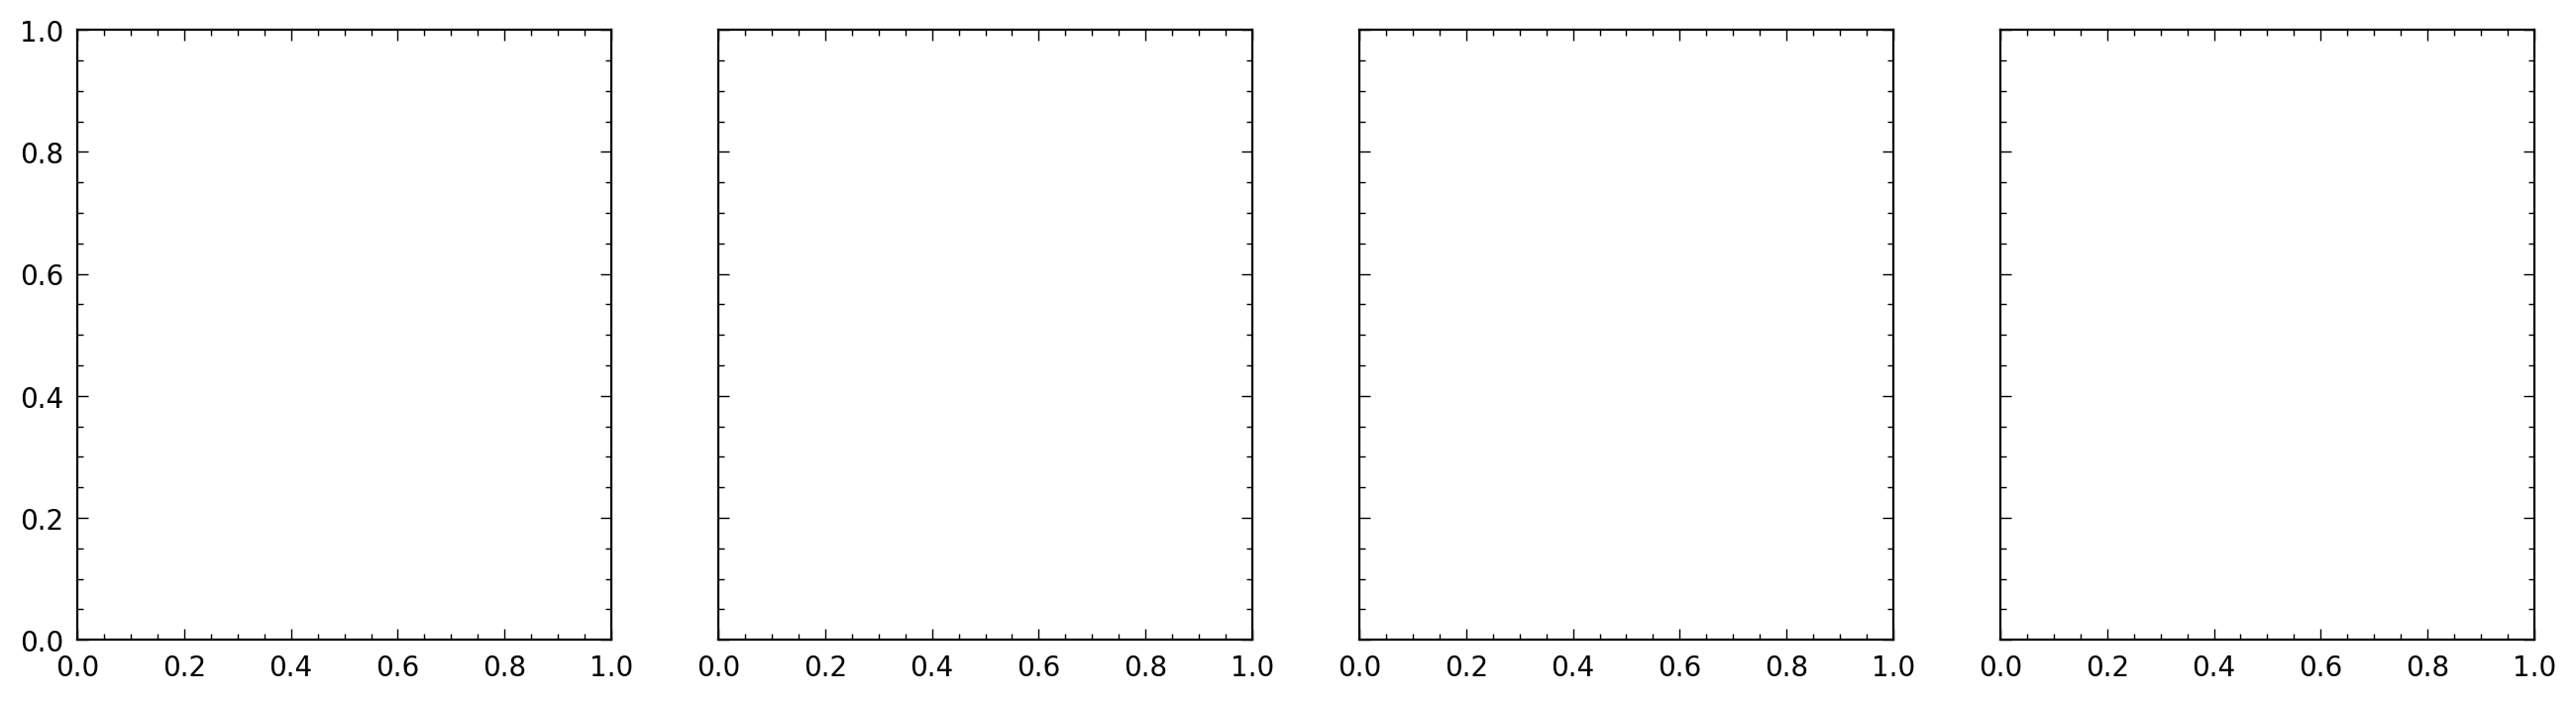

In [5]:
# Plot trends for different networks based on infection severity
n = len(virs)
rows = 1
fig, axs = plt.subplots(rows, int(np.ceil(n/rows)), figsize=(4*rows*n, n), sharex=False, sharey='row')

for l, (d_I, K_IE) in enumerate(virs):
    
    x,y = int(np.floor(rows*l/n)), l % int(np.ceil((n/rows)))
    
    data_mean = mean_df[(mean_df['d_I'] == d_I)*(mean_df['K_IE'] == K_IE)]
    data_std = std_df[(mean_df['d_I'] == d_I)*(mean_df['K_IE'] == K_IE)]
    
    S_min_over_S_0 = np.round(np.max(data_mean['min_pS']/data_mean['S_0']),2)
    var = 'harm_sIS_scaled' # change this to look at different variables
    im = axs[y].scatter(data_mean[var], data_std[var]/data_mean[var], 
                          c = data_std['max_pE_scaled'], cmap='coolwarm_r',
                          s = 15, marker ='s', alpha = 0.2)
    
    axs[y].set_title(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+r", $K_{IE} =$ "+str(np.round(K_IE/K_SE,5))+r"$\times K_{S,E}$"+"\n"+r"$min_{\psi}~\{ S_{min}/S_0 \} =$ "+str(S_min_over_S_0), fontsize =7.0)

fig.subplots_adjust(wspace=.25, hspace=.0)
cb = fig.colorbar(im, ax=axs, orientation='vertical', shrink = 0.6)
cb.set_label("1st effector response", fontsize = 12)

for j, ax in enumerate(axs.flat):
    if j % int(np.ceil(n/rows)) == 0:
        ax.set(ylabel=r"$\frac{Standard~deviation}{Mean}$")
    # if j >= int(np.ceil(n/rows)):
    ax.set(xlabel=r"$Mean$")
    
plt.savefig('_figs/'+comment+'-noise_in-'+var+'.png', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on infection severity
n = len(virs)
rows = 1

fig, axs = plt.subplots(rows, int(np.ceil(n/rows)), figsize=(4*n, n))#, sharex=True, sharey=True)

for l, (d_I, K_IE) in enumerate(virs):
    
    x,y = int(np.floor(rows*l/n)), l % int(np.ceil((n/rows)))
    
    data = mean_df[(mean_df['d_I'] == d_I)*(mean_df['K_IE'] == K_IE)].groupby(reg).mean()
    S_min_over_S_0 = np.round(np.max(data['min_pS']/data['S_0']),2)
    
    im = axs[y].scatter(data['harm_pI'] + data['harm_pS'], data['harm_sI'] + data['harm_sS'], 
            c = data['int_pE'], cmap='coolwarm_r', s = 15, marker ='o', alpha = 0.1)#,edgecolor = 'k', linewidth = 0.2)
    
    # axs[x,y].scatter(data['harm_pIS_scaled'][data['bio_reg'] == 1], data['harm_sIS_scaled'][data['bio_reg'] == 1], 
    #         color ='gold', s = 30, marker ='X', zorder=3, edgecolor = 'k', linewidth = 0.3) #, label = "Biologically evidenced")

    axs[y].set_title(r"$d_I =$ "+str(int(d_I/d_S))+r"$\times d_S$"+r", $K_{IE} =$ "+str(np.round(K_IE/K_SE,5))+r"$\times K_{S,E}$"+"\n"+r"$min_{\psi}~\{ S_{min}/S_0 \} =$ "+str(S_min_over_S_0), fontsize =7.0)
    
for j, ax in enumerate(axs.flat):
    if j % int(np.ceil(n/rows)) == 0:
        ax.set(ylabel="2nd infection total death \n (units of healthy death)")
    # if j >= int(np.ceil(n/rows)):
    ax.set_xlabel("1st infection total death \n (units of healthy death)", fontsize = 8)

fig.subplots_adjust(wspace=.3, hspace=.0)
cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label("1st effector response", fontsize = 12)
    
# plt.savefig('_figs/dI_K_IE_over_harm_pIS_v_harm_sIS'+'.png', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on infection severity
n = len(virs)

fig, axs = plt.subplots(rows, int(np.ceil(n/rows)), figsize=(4*n, n))#, sharex=True, sharey=True)

for l, (d_I, K_IE) in enumerate(virs):
    
    x,y = int(np.floor(rows*l/n)), l % int(np.ceil((n/rows)))
    
    data = mean_df[(mean_df['d_I'] == d_I)*(mean_df['K_IE'] == K_IE)].groupby(reg+['K_EI','K_EH']).mean()
    S_min_over_S_0 = np.round(np.max(data['min_pS']/data['S_0']),2)
    
    im = axs[y].scatter(data['min_pS']/S_0, data['min_sS']/S_0, 
            c = data['max_pE']/np.max(data['max_pE']), cmap='coolwarm_r', s = 15, marker ='o', alpha = 0.1)
        
    # axs[x,y].scatter(data['min_pS'][data['bio_reg'] == 1]/S_0, data['min_sS'][data['bio_reg'] == 1]/S_0, 
    #         color ='gold', s = 30, marker ='X', zorder=3, edgecolor = 'k', linewidth = 0.3) #, label = "Biologically evidenced")

    axs[y].set_title(r"$d_I =$ "+str(np.round(d_I,3))+r", $K_{IE} =$ "+str(np.round(K_IE,0))+r", $min_{\psi}~\{ \frac{S_{min}}{S_0}\} =$ "+str(S_min_over_S_0), fontsize = 7)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel="1st min. healthy cells",
           ylabel="2nd min. healthy cells")
    # ax.set_yscale('log')

for ax in axs.flat:
    ax.label_outer()

fig.subplots_adjust(wspace=.3, hspace=.0)
cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label("1st effector response", fontsize = 12)
    
# plt.savefig('_figs/dI_K_IE_over_min_pS_v_min_sS'+'.png', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on infection severity
n = len(virs)

fig, axs = plt.subplots(rows, int(np.ceil(n/rows)), figsize=(4*n, n))#, sharex=True, sharey=True)

for l, (d_I, K_IE) in enumerate(virs):
    
    x,y = int(np.floor(rows*l/n)), l % int(np.ceil((n/rows)))

    data = mean_df[(mean_df['d_I'] == d_I)*(mean_df['K_IE'] == K_IE)].groupby(reg + ['K_EI','K_EH']).mean()
    S_min_over_S_0 = np.round(np.mean(data['min_pS']/data['S_0']),2)
    
    # axs[y].scatter((data['harm_pS']/(data['d_S']*data['S_0']))[data['bio_reg'] == 1], (data['harm_sS']/(data['d_S']*data['S_0']))[data['bio_reg'] == 1], 
    #         color ='gold', s = 30, marker ='X', zorder=3, edgecolor = 'k', linewidth = 0.3) #, label = "Biologically evidenced")
    im = axs[y].scatter(data['harm_pS']/(data['d_S']*data['S_0']), data['harm_sS']/(data['d_S']*data['S_0']), 
            c = (1*data['inf_pM'] + 1*data['inf_pM'])/K_IE, cmap='coolwarm_r', s = 15, marker ='o', alpha = 0.1) #,edgecolor = 'k', linewidth = 0.2)
    axs[y].set_title("d_I = {}".format(np.round(d_I,2))+", K_IE = {}".format(K_IE)+", S_frac = {}".format(S_min_over_S_0), fontsize = 7)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel="1st excess death\n $\mathbb{E}[$"+stat_names[15]+r"$]$",
           ylabel="2nd excess death\n $\mathbb{E}[$"+stat_names[16]+r"$]$")
    # ax.set_yscale('log')

for ax in axs.flat:
    ax.label_outer()

fig.subplots_adjust(wspace=.3, hspace=.0)
cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label("1st memory response", fontsize = 12)

#plt.savefig('_figs/dI_v_p_resp_by_nets'+'.png', dpi=300, bbox_inches='tight')

In [ ]:
# Plot trends for different networks based on infection severity
n = len(virs)

fig, axs = plt.subplots(rows, int(np.ceil(n/rows)), figsize=(4*n, n))#, sharex=True, sharey=True)

for l, (d_I, K_IE) in enumerate(virs):
    
    x,y = int(np.floor(rows*l/n)), l % int(np.ceil((n/rows)))
    
    data = mean_df[(mean_df['d_I'] == d_I)*(mean_df['K_IE'] == K_IE)].groupby(reg + ['K_EI','K_EH']).mean()
        
    # axs[y].scatter(data['int_pE'][data['bio_reg'] == 1]/K_IE, data['int_sE'][data['bio_reg'] == 1]/K_IE, 
    #         color ='gold', s = 30, marker ='X', zorder=3, edgecolor = 'k', linewidth = 0.3)
    im = axs[y].scatter(data['int_pE']/K_IE, data['int_sE']/K_IE, 
            c = data['harm_sI']/(data['d_S']*data['S_0']), cmap='coolwarm', s = 15, marker ='o', alpha = 0.1) #,edgecolor = 'k', linewidth = 0.2)
    axs[y].set_title("d_I = {}".format(np.round(d_I,3))+", K_IE = {}".format(K_IE), fontsize = 8)
    
for i, ax in enumerate(axs.flat):
    ax.set(xlabel="1st effector response",
           ylabel="2nd effector response")
    # ax.set_yscale('log')

for ax in axs.flat:
    ax.label_outer()

fig.subplots_adjust(wspace=.3, hspace=.0)
cb = fig.colorbar(im, ax=axs, orientation='vertical')
cb.set_label("1st memory response", fontsize = 12)

#plt.savefig('_figs/dI_v_p_resp_by_nets'+'.png', dpi=300, bbox_inches='tight')

#### (b) Restrict analysis to data in the appropriate parameter regimes

Going forward we only want to consider data from infections that are Biologically realistic.

In [ ]:
# filter out entries that correspond to no regulation of any one transition
keep_data = (mean_df['K_IE'] == 1*K_IE_min)*(np.round(mean_df['d_I'],2) == 10*d_S)
p_mean_df = mean_df[keep_data].groupby(reg, 
                                as_index=False).mean()
s_mean_df = mean_df[keep_data].groupby(reg, 
                                as_index=False).mean()

# define data features
K_IEs = np.unique(mean_df['K_IE'])
d_Is = np.unique(mean_df['d_I'])
b_S = np.mean(mean_df['d_S']*mean_df['S_0'])
N_0 = np.mean(mean_df['N_0'])

p_harm_pI = p_mean_df['harm_pI']
s_harm_pI = s_mean_df['harm_pI']
s_harm_sI = s_mean_df['harm_sI']
p_harm_pS = p_mean_df['harm_pS']
s_harm_pS = s_mean_df['harm_pS']
s_harm_sS = s_mean_df['harm_sS']
s_harm_pIS = s_harm_pI + s_harm_pS
s_harm_sIS = s_harm_sI + s_harm_sS

s_max_sE = s_mean_df['max_sE']
s_max_pE = s_mean_df['max_pE']
p_max_pE = p_mean_df['max_pE']
s_int_sE = s_mean_df['int_sE']
s_int_pE = s_mean_df['int_pE']
p_int_pE = p_mean_df['int_pE']
p_max_peff = (p_mean_df['max_pE'] + p_mean_df['inf_pM'])
s_max_seff = (s_mean_df['max_sE'] + s_mean_df['inf_sM'])
s_max_peff = (s_mean_df['max_pE'] + s_mean_df['inf_pM'])
s_t_sE = s_mean_df['T_max_sE']
p_t_pE = p_mean_df['T_max_pE']
s_t_sI = s_mean_df['T_max_sI']

s_inf_sM = s_mean_df['inf_sM']
s_inf_sM = s_mean_df['inf_sM']
s_inf_pM = s_mean_df['inf_pM']
s_inf_pM = s_mean_df['inf_pM']
p_inf_pM = p_mean_df['inf_pM']
p_inf_pM = p_mean_df['inf_pM']
p_inf_pmem = p_mean_df['inf_pM'] 
s_inf_smem = s_mean_df['inf_sM'] 
s_inf_pmem = s_mean_df['inf_pM'] 

# identify Biologically evidenced networks
prim_true_reg = (p_mean_df['psi_NM_I'] > 0.0)*(p_mean_df['psi_NM_H'] > 0.0)*(p_mean_df['psi_NM_IH'] > 0.0)*1
true_reg = (p_mean_df['psi_NM_I'] > 0.0)*(p_mean_df['psi_NM_H'] > 0.0)*(p_mean_df['psi_NM_IH'] > 0.0)*1

In [ ]:
# plot distributions of response statistics
fig, axs = plt.subplots(1, 6, figsize=(18, 3), sharey = True)
axs[0].hist(p_harm_pI, bins='auto')
axs[1].hist(p_max_pE, bins='auto')
axs[2].hist(p_inf_pM, bins='auto')
axs[3].hist(p_inf_pM, bins='auto')
axs[4].hist(p_inf_pM/p_max_pE, bins='auto')
axs[5].hist(p_mean_df['min_pS']/S_0, bins='auto')

x_labs = ["1st infection excess death \n (units of healthy death)","Effector production \n (units of avidity)", 
          "Cental mem. production \n (units of avidity)", "Effector mem. production \n (units of avidity)", 
          "Memory to effector ratio","Minimum healthy cells \n (units of healthy death)"]
for i, ax in enumerate(axs.flat):
    ax.set(ylabel="Counts", 
           xlabel=x_labs[i])
    #ax.set_yscale('log')
    #ax.set_xscale('log')

for ax in axs.flat:
    ax.label_outer()
    
plt.savefig('_figs/'+comment+'-distribution-prim_resp'+'.png', dpi=300, bbox_inches='tight')

In [ ]:
# plot memory and effector response against infection excess death
fig, axs = plt.subplots(4, 1, figsize=(3, 12))
axs[0].scatter(p_harm_pI + p_harm_pS, p_mean_df['min_pS']/S_0, marker = 's', color = 'grey', alpha = 0.1)
axs[1].scatter(p_harm_pI + p_harm_pS, p_int_pE, marker = 's', color = 'grey', label = r"$\mathbb{E}[$"+stat_names[8]+r"$]$", alpha = 0.1)
axs[1].scatter((p_harm_pI + p_harm_pS)[prim_true_reg == 1], p_int_pE[prim_true_reg == 1], 
               color ='gold', s = 30, marker ='X', zorder=2, edgecolor = 'k', linewidth = 0.5)
axs[2].scatter(p_harm_pI + p_harm_pS, p_inf_pM, marker = 's', color = 'grey', label = r"$\mathbb{E}[$"+stat_names[12]+r"$]$", alpha = 0.1)
axs[3].scatter(p_harm_pI + p_harm_pS, (p_inf_pM)/p_max_pE, marker = 's', color = 'grey', label = r"$\mathbb{E}[$"+stat_names[8]+r"$]$", alpha = 0.1)
axs[3].scatter((p_harm_pI + p_harm_pS)[prim_true_reg == 1], ((p_inf_pM)/p_max_pE)[prim_true_reg == 1], 
               color ='gold', s = 30, marker ='X', zorder=2, edgecolor = 'k', linewidth = 0.5)

y_labs = ["Minimum healthy cells \n (units of healthy death)", "Effector production \n (units of avidity)", "Memory production \n (units of avidity)", "Memory to effector ratio"]
for i, ax in enumerate(axs.flat):
    ax.set(ylabel=y_labs[i], 
           xlabel='1st infection total harm \n (units of healthy death)')
    ax.semilogy()

for ax in axs.flat:
    ax.label_outer()
    
#plt.savefig('_figs/p_harm_v_p_resp'+'.png', dpi=300, bbox_inches='tight')

We also observe that there is essentially no relationship between the speed of a response and it's magnitude.

In [6]:
# plot time to peak effector response peak effector response
plt.scatter(p_t_pE, p_max_pE, c =p_harm_pI, cmap='coolwarm',marker = 's', label = r"$\mathbb{E}[$"+stat_names[12]+r"$]$", alpha = 0.2)
plt.colorbar(label ='1st infection excess death')

plt.xlabel(r"time to peak effector (days)")
plt.ylabel("1st infection effectors")
plt.legend()
#plt.semilogy()
# plt.savefig('_figs/p_eff_tmax_v_p_eff_w_E_regs'+'.png', dpi=300, bbox_inches="tight")

NameError: name 'p_t_pE' is not defined

There's a trade-off between producing effectors and central memory cells, which correlates with the excess death sustained during an infection. However, effector memory production scales with effector production, as expected. The networks that do a pretty good job at both effector and memory production tend to minimize excess death, but produce a lot more effector than memory.

In [ ]:
# plot time to memory response against effector response
plt.scatter(p_inf_pM, 
            p_int_pE, 
            c = p_harm_pI, 
            cmap='coolwarm', s = 15, marker='o', label = r"$\mathbb{E}[$"+stat_names[4]+r"$]$", alpha = 0.2)

plt.colorbar(label ="1st infection excess death\n"+"$\mathbb{E}[$"+stat_names[9]+r"$]$")

plt.xlabel(r"1st memory production")
plt.ylabel("1st effector production\n"+"$\mathbb{E}[$"+stat_names[17]+r"$]$")
plt.legend()
# plt.semilogx()
# plt.semilogy()
# plt.savefig('_figs/p_mem_v_p_eff'+'.png', dpi=300, bbox_inches="tight")

In [ ]:
# plot time to memory response against effector response
plt.scatter(p_int_pE, 
            p_inf_pM/p_int_pE, 
            c = p_harm_pI, 
            cmap='coolwarm', s = 15, marker='o', label = r"$\mathbb{E}[$"+stat_names[4]+r"$]$", alpha = 0.2)

plt.colorbar(label ="1st infection excess death\n"+"$\mathbb{E}[$"+stat_names[9]+r"$]$")

plt.xlabel(r"1st response effector")
plt.ylabel("1st response memory fraction")
plt.legend()
# plt.semilogx()
# plt.semilogy()
# plt.savefig('_figs/p_mem_v_p_eff'+'.png', dpi=300, bbox_inches="tight")

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = True)
thresh = np.mean(p_harm_pI)

axs[0].scatter(p_int_pE[p_harm_pI < thresh], 
            (p_inf_pM/p_int_pE)[p_harm_pI < thresh], 
            c = p_harm_pI[p_harm_pI < thresh], 
            cmap='coolwarm', s = 5, marker='o', label = r"Top average utility", alpha = 0.15)
axs[1].scatter(p_int_pE[p_harm_pI >= thresh], 
            (p_inf_pM/p_int_pE)[p_harm_pI >= thresh], 
            c = p_harm_pI[p_harm_pI >= thresh], 
            cmap='coolwarm', s = 5, marker='o', label = r"below average utility", alpha = 0.15)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), sharey = True)
thresh = np.mean(p_harm_pI)

axs[0].scatter(p_int_pE[p_harm_pI < thresh], 
            (p_inf_pM/p_int_pE)[p_harm_pI < thresh], 
            c = p_harm_pI[p_harm_pI < thresh], 
            cmap='coolwarm', s = 5, marker='o', label = r"Top average utility", alpha = 0.15)
axs[0].semilogx()
axs[1].scatter(p_int_pE[p_harm_pI >= thresh], 
            (p_inf_pM/p_int_pE)[p_harm_pI >= thresh], 
            c = p_harm_pI[p_harm_pI >= thresh], 
            cmap='coolwarm', s = 5, marker='o', label = r"below average utility", alpha = 0.15)
axs[1].semilogx()

In [ ]:
# plot distributions of response statistics
fig, axs = plt.subplots(1, 5, figsize=(15, 3), sharey = True)
axs[0].hist(s_harm_sI, bins='auto')
axs[1].hist(s_max_sE, bins='auto')
axs[2].hist(s_inf_sM, bins='auto')
axs[3].hist((s_inf_sM/s_max_sE), bins='auto')
axs[4].hist(s_mean_df['min_sS']/S_0, bins='auto')

x_labs = ["2nd infection excess death \n (units of healthy death)","Effector production \n (units of avidity)", 
          "Mem. production \n (units of avidity)", 
          "Memory to effector ratio","Minimum healthy cells \n (units of healthy death)"]
for i, ax in enumerate(axs.flat):
    ax.set(ylabel="Counts", 
           xlabel=x_labs[i])
    #ax.set_yscale('log')
    #ax.set_xscale('log')

for ax in axs.flat:
    ax.label_outer()
    
plt.savefig('_figs/'+comment+'-distribution-sec_resp'+'.png', dpi=300, bbox_inches='tight')

In [ ]:
# plot memory and effector response against infection excess death
fig, axs = plt.subplots(4, 1, figsize=(3, 12))
axs[0].scatter(s_harm_sI, s_max_sE, marker = 's', color = 'gray', label = r"$\mathbb{E}[$"+stat_names[12]+r"$]$", alpha = 0.1)
axs[1].scatter(s_harm_sI, s_inf_sM, marker = 's', color = 'gray', label = r"$\mathbb{E}[$"+stat_names[8]+r"$]$", alpha = 0.1)
axs[2].scatter(s_harm_sI + s_harm_sS, (s_inf_sM)/s_max_sE, marker = 's', color = 'gray', label = "Memory fraction", alpha = 0.1)
axs[2].scatter((s_harm_sI + s_harm_sS)[true_reg == 1], ((s_inf_sM + s_inf_sM)/s_max_sE)[true_reg == 1], 
               color ='gold', s = 30, marker ='X', zorder=2, edgecolor = 'k', linewidth = 0.5)
axs[3].scatter(s_harm_sI, s_mean_df['min_sS']/S_0, marker = 's', color = 'gray', alpha = 0.1)

x_labs = ["Effector production", "Mem. production", "Memory to effector ratio","Minimum healthy cells"]
for i, ax in enumerate(axs.flat):
    ax.set(ylabel=x_labs[i], 
           xlabel='2nd infection total harm')
    if i == 2:
        ax.set_yscale('log')
    #ax.set_xscale('log')

for ax in axs.flat:
    ax.label_outer()
    
# plt.savefig('_figs/s_harm_v_s_resp'+'.png', dpi=300, bbox_inches='tight')

In [ ]:
plt.scatter(s_t_sE[true_reg == 1], s_max_seff[true_reg == 1], 
            color ='gold', s = 30, marker ='X', zorder=1, edgecolor = 'k', linewidth = 0.5)
plt.scatter(s_t_sE, s_max_sE, c = s_harm_sI, 
            cmap='coolwarm', s = 15, marker ='o', zorder=0, alpha = 0.2) #, edgecolor = 'k', linewidth = 0.1)
plt.colorbar(label ="2nd infection excess death")
plt.ylabel("2nd effector response")
plt.xlabel("timescale of effector response")

#plt.semilogy()

# plt.savefig('_figs/t_max_eff_v_harm_sI.png', dpi=300, bbox_inches="tight")

In [ ]:
# Simple regression analysis of regulatory effects
var_names = reg

lr = LinearRegression()
lr.fit(mean_df[var_names], mean_df['harm_pIS_scaled']) # X = log-scaled-parameter values, centered at default value
first_data = lr.coef_/lr.intercept_ # scale coefficients by value at default value to give interpretability.

lr.fit(mean_df[var_names], mean_df['harm_sIS_scaled']) # X = log-scaled-parameter values, centered at default value
sec_data = lr.coef_/lr.intercept_ # scale coefficients by value at default value to give interpretability.

r = np.arange(0,len(var_names))
width = 0.5

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].bar(r, first_data, width = width)
axs[0].set_xticks(r)
axs[0].set_xticklabels(param_names[-len(var_names):], fontsize = 7)

axs[1].bar(r, sec_data, width = width)
axs[1].set_xticks(r)
axs[1].set_xticklabels(param_names[-len(var_names):], fontsize = 7)

## 2. Exploratory analysis of trade-offs in the immune response

In [ ]:
z = p_t_pE
low = 0.0

# plt.scatter(p_max_pE[true_reg == 1], p_harm_pI[true_reg == 1], 
#             color ='gold', s = 50, 
#             marker ='X', zorder=3, edgecolor = 'k', linewidth = 0.3, label = "Biologically evidenced")
plt.scatter(p_max_pE[(p_max_pE >= low)], p_harm_pI[(p_max_pE >= low)], 
            c = z[(p_max_pE >= low)], cmap = plt.cm.coolwarm, 
            s = 15, marker ='o', zorder = 1, alpha = 0.2) #, edgecolor = 'k', linewidth = 0.2)
plt.colorbar(label ="Timescale of effector response \n $\mathbb{E}[$"+stat_names[19]+r"$]$")

#plt.scatter(p_harm[(p_max_eff >= high)], harm[(p_max_eff >= high)], c = p_max_eff[(p_max_eff >= high)], cmap='coolwarm', s = 15,marker ='^')
plt.xlabel("1st effector response \n $\mathbb{E}[$"+stat_names[12]+r"$]$", fontsize = 14)
plt.ylabel("1st infection excess death\n $\mathbb{E}[$"+stat_names[10]+r"$]$", fontsize = 14)
#plt.semilogy()
#plt.semilogx()

# plt.savefig('_figs/p_harm_v_pE_w_t_pE.png', dpi=300, bbox_inches="tight")

#### (a) Network architectures that optimize evolutionary anticipation

Cell death caused by collateral during 1st infections scales with excess cell death due to the infection

In [ ]:
z = s_int_pE #/max_pE
low, high = K_IE*0, 50_000_000

# plt.scatter(s_harm_pS[true_reg == 1], s_harm_pI[true_reg == 1], 
#             color ='gold', s = 30, marker ='X', zorder=3, edgecolor = 'k', linewidth = 0.3, label = "Biologically evidenced")
plt.scatter(s_harm_pS[(s_max_peff >= low)], s_harm_pI[(s_max_peff >= low)], 
            c = z[(s_max_peff >= low)],
            cmap='coolwarm_r', s = 15, marker ='o', alpha = 0.2)
plt.colorbar(label ="1st effector response")

plt.xlabel("1st collateral excess death", fontsize = 12)
plt.ylabel("1st infection excess death", fontsize = 12)

# plt.savefig('_figs/harm_pI_v_harm_pS_w_max_pE.png', dpi=300, bbox_inches="tight")

In [ ]:
s_mean_df['bias'] = -(s_mean_df['psi_NM_I'] + s_mean_df['psi_NM_H'] + s_mean_df['psi_NM_IH'])
s_mean_df['coherence'] = s_mean_df['psi_NM_I']*s_mean_df['psi_NM_H']*(s_mean_df['psi_NM_I'] > 0)
fig = px.scatter(s_mean_df, y = 'harm_sI_scaled', x = reg[4], color = 'coherence',
                 labels ={"harm_pI_scaled": "1st infection excess death",
                          "harm_pS_scaled": "1st collateral excess death",
                          'harm_sI_scaled': "2nd infection excess death",
                          "harm_sS_scaled": "2nd collateral excess death",
                           'int_sresp_scaled': "2nd effector response",
                          "inf_pM_scaled": "1st memory response"} ,
                 width = 650,
                 height = 500,
                 hover_data = reg + ['K_EI','K_EH'],
                log_y = False, log_x = False)

fig.update_layout(
    plot_bgcolor='white'
)

fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black'
)

fig.show()
# fig.write_html('_figs/p_harm_v_harm_w_p_eff_regs.html')